In [1]:
import numpy as np
import hmm
import emission_model

In [2]:
import numpy as np

# HMM parameters
A_optimal = np.array([
    [0.75, 0.25],
    [0.35, 0.65],
])

B_optimal = np.array([
    [0.1, 0.2],  # state 0
    [-0.05, 0.5],  # state 1
])

pi = np.array([0.5, 0.5])  # Initial state distribution

def generate_hmm_sequence(A, B, pi, seq_length):
    num_states = A.shape[0]
    num_obs = B.shape[1]

    states = []
    observations = []

    # Initial state
    current_state = np.random.choice(num_states, p=pi)
    states.append(current_state)

    # Emit first observation
    #first_obs = np.random.choice(num_obs, p=B[current_state])
    first_obs = np.random.normal(B[current_state, 0], B[current_state, 1])
    
    observations.append(first_obs)

    # Generate the rest
    for _ in range(1, seq_length):
        current_state = np.random.choice(num_states, p=A[current_state])
        states.append(current_state)
        #obs = np.random.choice(num_obs, p=B[current_state])
        obs = np.random.normal(B[current_state, 0], B[current_state, 1])
        observations.append(obs)

    return np.array(observations), np.array(states)  # Return both for validation

# Example: Generate 5 sequences of length 20
num_sequences = 10
sequence_length = 1000
obs_sequences = []
true_state_sequences = []

for _ in range(num_sequences):
    obs_seq, state_seq = generate_hmm_sequence(A_optimal, B_optimal, pi, sequence_length)
    obs_sequences.append(obs_seq)
    true_state_sequences.append(state_seq)

In [3]:
data_obs = np.array(obs_sequences)
print(np.array(obs_sequences).shape)

(10, 1000)


In [5]:
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    gauss_params = np.array([
    [0.02, 0.1],  # state 0
    [-0.2, 0.1],  # state 1
])
    emission = emission_model.Gaussian_Emission(2, data_obs, gauss_params=gauss_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=100, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

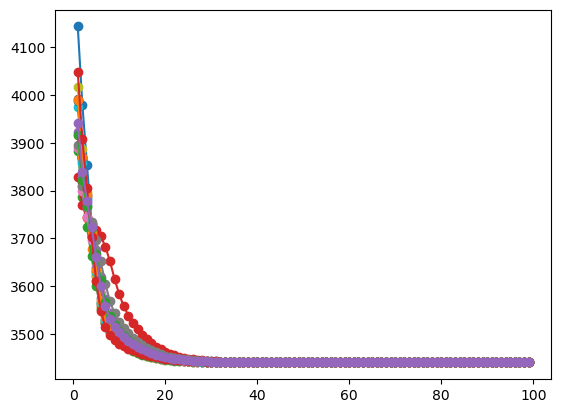

In [6]:
import matplotlib.pyplot as plt

for i in range(15):
    
    plt.plot(range(1, np.array(err).shape[1]-1), -np.array(err)[i, 2:], marker='o')


In [7]:
print(HMM_list[-5].emission.gauss_params)

[[ 0.09649053  0.20065552]
 [-0.05568116  0.49988308]]


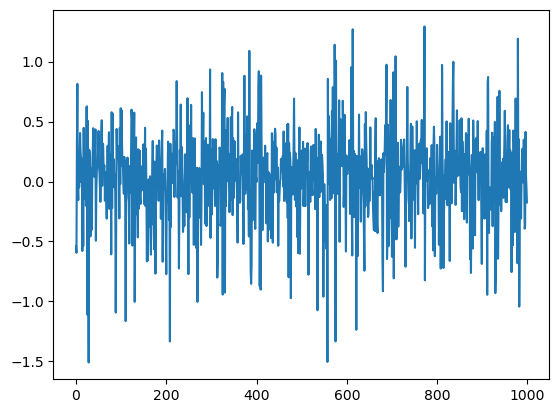

In [8]:
plt.plot(data_obs[0, :])

(array([ 2.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,  1.,
         0.,  2.,  1.,  1.,  0.,  2.,  2.,  4.,  2.,  1.,  1.,  1.,  3.,
         8.,  3.,  2.,  4.,  8.,  4.,  5.,  6., 10.,  8.,  8.,  9.,  6.,
         8., 11., 12., 14.,  9.,  9., 17., 24., 22., 34., 24., 29., 36.,
        33., 37., 34., 40., 41., 32., 42., 26., 51., 35., 29., 38., 28.,
        22., 25., 10., 11., 20.,  9.,  8., 11.,  5.,  8.,  6.,  6.,  1.,
         5.,  1.,  2.,  4.,  1.,  4.,  2.,  2.,  3.,  2.,  2.,  2.,  0.,
         1.,  1.,  0.,  1.,  0.,  1.,  0.,  0.,  2.]),
 array([-1.50883276, -1.48081608, -1.4527994 , -1.42478272, -1.39676605,
        -1.36874937, -1.34073269, -1.31271601, -1.28469933, -1.25668266,
        -1.22866598, -1.2006493 , -1.17263262, -1.14461594, -1.11659926,
        -1.08858259, -1.06056591, -1.03254923, -1.00453255, -0.97651587,
        -0.9484992 , -0.92048252, -0.89246584, -0.86444916, -0.83643248,
        -0.80841581, -0.78039913, -0.75238245, -0.72436577, -0.696349

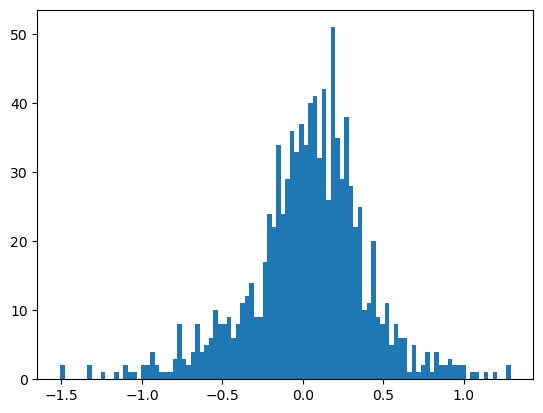

In [10]:
plt.hist(data_obs[0, :], bins=100)

In [12]:
import yfinance as yf

In [19]:
import yfinance as yf

data = yf.download("SPY", start="2000-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [20]:
import os

filepath = "data/sp500.csv"

if os.path.exists(filepath):
    data = pd.read_csv(filepath, index_col=0, parse_dates=True)
else:
    data = yf.download("SPY", start="2000-01-01", end="2024-01-01")
    os.makedirs("data", exist_ok=True)
    data.to_csv(filepath)

Failed to get ticker 'SPY' reason: HTTPSConnectionPool(host='query2.finance.yahoo.com', port=443): Read timed out. (read timeout=10)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPY']: YFTzMissingError('possibly delisted; no timezone found')


In [21]:
import pandas_datareader as pdr

# Stooq — gratuito, no API key
data = pdr.get_data_stooq("^SPX", start="2000-01-01", end="2024-01-01")

ParserError: Error tokenizing data. C error: Expected 1 fields in line 6, saw 2
